### Analytical Forward Model 
#### with inital ensemble setup based on known values
##### combination of Sisson/Brooks-Corey analytical solution and forward model process for TDEM response

Imports

In [267]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import itertools
from simpeg import maps
from simpeg.electromagnetics import time_domain as tdem
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


User inputs

In [268]:
### Set run mode of ensemble
run_mode = "texture_excel" ### options: known_soils, parameter_range, texture_excel

### set soil type parameter options for "truth" forward model
truth_soil_type = "custom"  ### options: custom, sand, loamy sand, sandy loam, loam, silt, silt loam, clay


 Desired scenario to plot must be selected in section 5, without explitic selection the next iteration will be use

In [269]:
""" theta_scenario_to_plot = next(iter(theta_results))                 ### = eplicit scenario or exsiting soil type"""    

' theta_scenario_to_plot = next(iter(theta_results))                 ### = eplicit scenario or exsiting soil type'

### 1. Define variables
##### 1.1 Soil Column and Timestamps

In [270]:
z = np.linspace(1, 2000, 300)  # cm, positive downward (20m soil column)
times = [1, 4, 12, 24, 48]   # hr

#### 1.2 ROSETTA/vG style soil parameter library

In [271]:
### Custom option for "Truth" ensemble 
custom_vg_params = {
    "custom": {
    "theta_r": 0.05,
    "theta_s": 0.4,
    "alpha": 0.1,
    "n": 2.0,
    "Ks": 10.0,
    "l": 0.5
}}
### OR preset values for sand, loamy sand, sandy loam, loam, silt, silt loam, clay

known_soils = {
    "sand": {
        "theta_r": 0.045,
        "theta_s": 0.43,
        "alpha": 0.145,
        "vg_n": 2.68,
        "Ks": 29.7,
    },
    "loamy_sand": {
        "theta_r": 0.057,
        "theta_s": 0.41,
        "alpha": 0.124,
        "vg_n": 2.28,
        "Ks": 14.6,
    },
    "sandy_loam": {
        "theta_r": 0.065,
        "theta_s": 0.41,
        "alpha": 0.075,
        "vg_n": 1.89,
        "Ks": 4.42,
    },
    "loam": {
        "theta_r": 0.078,
        "theta_s": 0.43,
        "alpha": 0.036,
        "vg_n": 1.56,
        "Ks": 1.04,
    },
    "silt": {
        "theta_r": 0.085,
        "theta_s": 0.45,
        "alpha": 0.025,
        "vg_n": 1.35,
        "Ks": 0.52,
    },
    "silty_loam": {
        "theta_r": 0.09,
        "theta_s": 0.46,
        "alpha": 0.02,
        "vg_n": 1.25,
        "Ks": 0.35,
    }, 
    "clay": {
        "theta_r": 0.1,
        "theta_s": 0.47,
        "alpha": 0.015,
        "vg_n": 1.15,
        "Ks": 0.2,
    }      
}

## 2. Analytical Solution
### 2.1 Conversion Functions

In [272]:
def vg_m(vg_n):
    """
    van Genuchten m parameter.
    """
    return 1 - (1 / vg_n)

def kr_vg_mualem(Se, vg_n, l=0.5):
    """
    van Genuchten-Mualem relative hydraulic conductivity.

    Se : effective saturation, between 0 and 1
    vg_n : van Genuchten n
    l : pore-connectivity/tortuosity parameter, commonly 0.5
    """
    Se = np.asarray(Se, dtype=float)
    Se = np.clip(Se, 1e-8, 1.0)

    m = vg_m(vg_n)

    Kr = Se**l * (1 - (1 - Se**(1 / m))**m)**2

    return Kr

### 2.2 Fitted Brooks-Corey Exponent for Each Soil Type

In [273]:
def fit_n_sisson_to_vg_mualem(vg_n, Se_min=0.1, Se_max=0.95, l=0.5):
    """
    Fit the Sisson/Brooks-Corey exponent n_sisson so that
    Kr = Se^(1/n_sisson) approximates the van Genuchten-Mualem curve.
    """

    Se = np.linspace(Se_min, Se_max, 300)
    Kr_vg = kr_vg_mualem(Se, vg_n=vg_n, l=l)

    # Avoid log of zero
    valid = (Kr_vg > 0) & (Se > 0)

    x = np.log(Se[valid])
    y = np.log(Kr_vg[valid])

    # Force fit through origin because log(Kr) = slope * log(Se)
    slope = np.sum(x * y) / np.sum(x * x)

    n_fit = 1 / slope

    return n_fit

In [274]:
for soil_name, item in known_soils.items():
    known_soils[soil_name]["bc_n_fitted"] = fit_n_sisson_to_vg_mualem(
        known_soils[soil_name]["vg_n"],
        Se_min=0.1,
        Se_max=0.95,
        l=0.5
    )

### 3. Analytical Solution Sisson/Brooks-Corey 

In [275]:
def theta_brooks_corey_sisson_piecewise(
        z, t, theta_r, theta_s, Ks, bc_n, q0,
        return_star_mid=False,
        debug=False):

    z = np.asarray(z, dtype=float)

    if t <= 0:
        return np.full_like(z, theta_s)

    # Transformed depth for saturated initial condition
    z_star = (Ks / q0) ** bc_n * z

    # Sisson variable: z*/t
    s_star = np.maximum(z_star / t, 1e-12)

    # Brooks-Corey derivative setup
    A = Ks / (bc_n * (theta_s - theta_r))
    exponent = 1 / ((1 / bc_n) - 1)

    # Middle transformed solution
    theta_star_mid = theta_r + (theta_s - theta_r) * (s_star / A) ** exponent

    if debug:
        print("bc_n =", bc_n)
        print("Ks =", Ks)
        print("q0 =", q0)
        print("A =", A)
        print("exponent =", exponent)
        print("z_star min =", z_star.min())
        print("z_star max =", z_star.max())
        print("s_star min =", s_star.min())
        print("s_star max =", s_star.max())
        print("theta_star_mid min =", theta_star_mid.min())
        print("theta_star_mid max =", theta_star_mid.max())

    if return_star_mid:
        return theta_star_mid

    # Piecewise solution based on Sisson Eq. 15

    theta_star = np.clip(theta_star_mid, theta_r, theta_s)

    return theta_star

### 4. Ensemble
### 4.1 Setup "Truth" Model 

#### Choose parameters for "Truth" based on user input :NOTE:No truth model used for comparison at this time 7/1/26
#### Custom values OR sand, loamy sand, sandy loam, loam, silt, silt loam, clay

In [276]:
"""def truth_vg_params(soil_type):
    truth_soil_type = soil_type.lower().strip()
    if truth_soil_type in known_soils:
        return known_soils[truth_soil_type]
    elif truth_soil_type == "custom":
        return custom_vg_params["custom"]
    else:
        print(f"Warning: Unrecognized soil type '{soil_type}'. Defaulting to 'loam' parameters.")
        return known_soils["loam"]


truth_vg_params = truth_vg_params(
    soil_type=truth_soil_type,
    )

print(truth_vg_params)"""

'def truth_vg_params(soil_type):\n    truth_soil_type = soil_type.lower().strip()\n    if truth_soil_type in known_soils:\n        return known_soils[truth_soil_type]\n    elif truth_soil_type == "custom":\n        return custom_vg_params["custom"]\n    else:\n        print(f"Warning: Unrecognized soil type \'{soil_type}\'. Defaulting to \'loam\' parameters.")\n        return known_soils["loam"]\n\n\ntruth_vg_params = truth_vg_params(\n    soil_type=truth_soil_type,\n    )\n\nprint(truth_vg_params)'

### 4.2 Ensemble- Process a range of parameters
##### Parameter ranges based off of exsisting known soil types [Look to edit later im not sure this is the best approach]

In [277]:
texture_excel_path = Path("C:/Users/natal/OneDrive/Desktop/26' HYDROGEO/Project [THESIS]/soils_texture_data_20191028.xlsx")

print("File exists:", texture_excel_path.exists())

xl = pd.ExcelFile(texture_excel_path)
print("Sheet names:", xl.sheet_names)

texture_df = pd.read_excel(texture_excel_path, sheet_name="soil texture data")

print(texture_df.head())
print(texture_df.columns)
print(texture_df.shape)

File exists: True
Sheet names: ['soil texture data']
   sand  silt  clay USDA Class     thr     ths  Alfa (1/cm)       n  \
0     0     0   100       clay  0.1095  0.4968       0.0159  1.1548   
1     0     2    98       clay  0.1087  0.5015       0.0165  1.1529   
2     0     4    96       clay  0.1081  0.5058       0.0172  1.1520   
3     0     6    94       clay  0.1077  0.5096       0.0178  1.1525   
4     0     8    92       clay  0.1074  0.5130       0.0184  1.1541   

   Ks (cm/day)  
0        18.49  
1        18.23  
2        17.97  
3        17.88  
4        17.80  
Index(['sand', 'silt', 'clay', 'USDA Class', 'thr', 'ths', 'Alfa (1/cm)', 'n',
       'Ks (cm/day)'],
      dtype='object')
(1326, 9)


In [278]:
from pathlib import Path

texture_excel_path = Path("C:/Users/natal/OneDrive/Desktop/26' HYDROGEO/Project [THESIS]/soils_texture_data_20191028.xlsx")

texture_df = pd.read_excel(texture_excel_path, sheet_name="soil texture data")

texture_step = 4  # options from current 2% sheet: 10 (66), 4 (351), or 2 (1326)

texture_df_subset = texture_df[
    (texture_df["sand"] % texture_step == 0) &
    (texture_df["silt"] % texture_step == 0) &
    (texture_df["clay"] % texture_step == 0)
].copy()

print(f"Using {len(texture_df_subset)} texture cases")

texture_excel_scenarios = {}

for row_id, row in texture_df_subset.iterrows():

    scenario_name = (
        f"sand{int(row['sand']):03d}_"
        f"silt{int(row['silt']):03d}_"
        f"clay{int(row['clay']):03d}"
    )

    vg_n = row["n"]
    Ks_cm_hr = row["Ks (cm/day)"] / 24

    texture_excel_scenarios[scenario_name] = {
        "base_soil": row["USDA Class"],
        "sand": row["sand"],
        "silt": row["silt"],
        "clay": row["clay"],
        "USDA_class": row["USDA Class"],
        "theta_r": row["thr"],
        "theta_s": row["ths"],
        "alpha": row["Alfa (1/cm)"],
        "vg_n": vg_n,
        "Ks": Ks_cm_hr,
        "bc_n": fit_n_sisson_to_vg_mualem(vg_n),
        "q0": Ks_cm_hr
    }

print(f"Built {len(texture_excel_scenarios)} texture scenarios")

Using 351 texture cases
Built 351 texture scenarios


In [ ]:
if run_mode == "known_soils":

    scenarios_to_run = {
        soil_name: {
            "base_soil": soil_name,
            "theta_r": soil["theta_r"],
            "theta_s": soil["theta_s"],
            "alpha": soil["alpha"],
            "vg_n": soil["vg_n"],
            "Ks": soil["Ks"],
            "l": soil.get("l", 0.5),
            "bc_n": soil["bc_n_fitted"],
            "q0": soil["Ks"]
        }
        for soil_name, soil in known_soils.items()
    }

elif run_mode == "parameter_range":

    scenarios_to_run = parameter_range_scenarios.copy()

elif run_mode == "texture_excel":

    scenarios_to_run = texture_excel_scenarios.copy()

else:
    raise ValueError(
        "run_mode must be 'known_soils', 'parameter_range', or 'texture_excel'"
    )

### 4.3 Build ensemble
#### Loop through each exsisting scenario
#### Edit the desired fixed and changing parameters ***

In [280]:
theta_results = {}
results = []

for scenario_name, params in scenarios_to_run.items():

    print(
        f"Running {scenario_name}: "
        f"Ks={params['Ks']:.4f}, bc_n={params['bc_n']:.4f}"
    )

    theta_results[scenario_name] = {}

    for t in times:
        theta = theta_brooks_corey_sisson_piecewise(
            z=z,
            t=t,
            theta_r=params["theta_r"],
            theta_s=params["theta_s"],
            Ks=params["Ks"],
            bc_n=params["bc_n"],
            q0=params["q0"],
            debug=False
        )

        theta_results[scenario_name][t] = theta

    results.append({
        "scenario": scenario_name,
        "base_soil": params.get("base_soil", np.nan),
        "USDA_class": params.get("USDA_class", params.get("base_soil", np.nan)),
        "sand": params.get("sand", np.nan),
        "silt": params.get("silt", np.nan),
        "clay": params.get("clay", np.nan),
        "theta_r": params["theta_r"],
        "theta_s": params["theta_s"],
        "alpha": params.get("alpha", np.nan),
        "vg_n": params.get("vg_n", np.nan),
        "bc_n": params["bc_n"],
        "Ks": params["Ks"],
        "q0": params["q0"]
    })
    
results_df = pd.DataFrame(results)
results_df.to_csv("analytical_ensemble_summary.csv", index=False)

Running sand000_silt000_clay100: Ks=0.7704, bc_n=0.0534
Running sand000_silt004_clay096: Ks=0.7487, bc_n=0.0527
Running sand000_silt008_clay092: Ks=0.7417, bc_n=0.0533
Running sand000_silt012_clay088: Ks=0.7379, bc_n=0.0549
Running sand000_silt016_clay084: Ks=0.7308, bc_n=0.0572
Running sand000_silt020_clay080: Ks=0.7129, bc_n=0.0600
Running sand000_silt024_clay076: Ks=0.7021, bc_n=0.0631
Running sand000_silt028_clay072: Ks=0.7558, bc_n=0.0668
Running sand000_silt032_clay068: Ks=0.9683, bc_n=0.0709
Running sand000_silt036_clay064: Ks=1.1700, bc_n=0.0755
Running sand000_silt040_clay060: Ks=1.0654, bc_n=0.0805
Running sand000_silt044_clay056: Ks=0.8279, bc_n=0.0860
Running sand000_silt048_clay052: Ks=0.6658, bc_n=0.0922
Running sand000_silt052_clay048: Ks=0.5617, bc_n=0.0988
Running sand000_silt056_clay044: Ks=0.4896, bc_n=0.1055
Running sand000_silt060_clay040: Ks=0.4321, bc_n=0.1117
Running sand000_silt064_clay036: Ks=0.3817, bc_n=0.1173
Running sand000_silt068_clay032: Ks=0.3525, bc_n

### 5. Plot water content vs Depth over time

### 5.1 reusable water content plotting function

In [281]:
def plot_theta_profiles(theta_results, scenario_name, z):
    """Plot water-content profiles through drainage time."""

    plt.figure(figsize=(6, 7))

    for t, theta_profile in theta_results[scenario_name].items():

        plt.plot(
            theta_profile,
            z,
            label=f"{t} hr"
        )

    plt.gca().invert_yaxis()
    plt.xlabel("Water content, theta")
    plt.ylabel("Depth [cm]")
    plt.title(f"Analytical drainage: {scenario_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Assign a specific scenario to plot, or allow the next iteration 

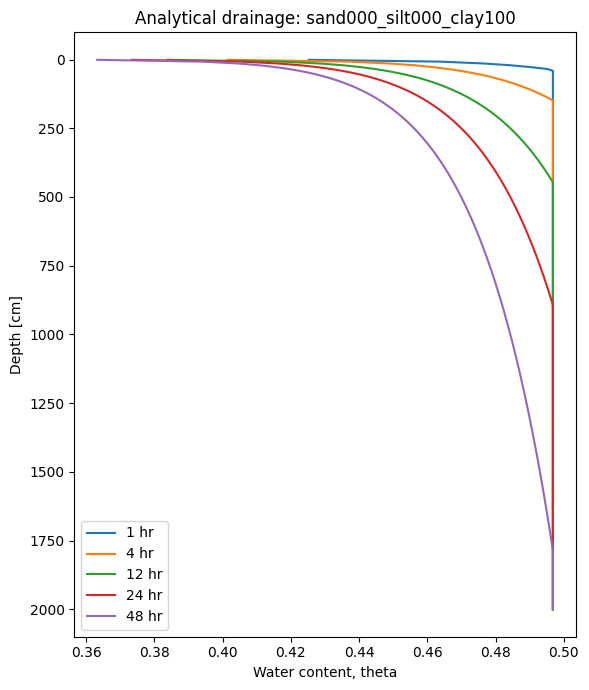

In [282]:
theta_scenario_to_plot = next(iter(theta_results))   ### = eplicit scenario or exsiting soil type 

plot_theta_profiles(
    theta_results=theta_results,
    scenario_name=theta_scenario_to_plot,
    z=z
)

### 6. Use Archies Law to convert water content to electrical conductivity. 

In [283]:
def theta_to_conductivity(theta, sigma_w, m_archie):
    """
    Convert volumetric water content to bulk electrical
    conductivity using simplified Archie's law.
    """
    sigma_bulk = sigma_w * theta**m_archie

    return sigma_bulk


# Archie parameters used for all scenarios
sigma_w = 0.1       # Water conductivity [S/m] - adjust as needed
m_archie = 1.5      # Cementation exponent - adjust as needed


# Convert every analytical theta profile to conductivity
sigma_matrices = {}

for scenario_name, time_dict in theta_results.items():

    conductivity_profiles = {}

    for t, theta_profile in time_dict.items():

        sigma_profile = theta_to_conductivity(
            theta=theta_profile,
            sigma_w=sigma_w,
            m_archie=m_archie
        )

        conductivity_profiles[t] = sigma_profile

    sigma_matrix = pd.DataFrame(
        conductivity_profiles,
        index=z
    )

    sigma_matrix.index.name = "depth_cm"

    sigma_matrices[scenario_name] = sigma_matrix

In [284]:
first_scenario = next(iter(sigma_matrices))

print("Displayed scenario:", first_scenario)
display(sigma_matrices[first_scenario].head())

Displayed scenario: sand000_silt000_clay100


,1,4,12,24,48
depth_cm,,,,,
1.000000,0.027732,0.025439,0.023788,0.022816,0.021894
7.685619,0.031586,0.028900,0.026968,0.025831,0.024753
14.371237,0.032896,0.030077,0.028049,0.026855,0.025724
21.056856,0.033729,0.030824,0.028734,0.027505,0.026340
27.742475,0.034345,0.031377,0.029242,0.027986,0.026796


### 7. SimPEG Forward Model 
#### 7.1 Layered model at 1 time
is this description still accurate??
extract one ec profile at one time step and determine expected TEM response, create a 1D layered TDEM forward model using SimPEG tutorial

In [285]:
# SimPEG TEM forward model from the electrical conductivity matrix

def build_tem_simulation(
    layer_thicknesses_m,
    loop_side_length_m=20.0,
    height_m=0.0,
    tem_times=None
):
    """Build one layered TDEM simulation for all ensemble profiles."""

    if tem_times is None:
        tem_times = np.logspace(-7, -2, 61)

    layer_thicknesses_m = np.asarray(
        layer_thicknesses_m,
        dtype=float
    )

    n_layers = len(layer_thicknesses_m) + 1

    receiver = tdem.receivers.PointMagneticFluxDensity(   ### OR receiver = tdem.receivers.PointMagneticFluxTimeDerivative(
        locations=np.array([[0.0, 0.0, height_m]]),
        times=tem_times,
        orientation="z"
    )

    # Equivalent-area circular loop for a 20 m x 20 m square loop
    loop_area = loop_side_length_m**2
    loop_radius = np.sqrt(loop_area / np.pi)

    source = tdem.sources.CircularLoop(
        receiver_list=[receiver],
        location=np.array([0.0, 0.0, height_m]),
        radius=loop_radius,
        orientation="z",
        waveform=tdem.sources.StepOffWaveform()
    )

    survey = tdem.Survey([source])

    conductivity_map = maps.IdentityMap(nP=n_layers)

    simulation = tdem.simulation_1d.Simulation1DLayered(
        survey=survey,
        sigmaMap=conductivity_map,
        thicknesses=layer_thicknesses_m
    )

    return simulation, tem_times

### 7.2 Layered model at all times

In [286]:
# Run TEM forward model for every timestep

# All analytical scenarios use the same depth grid
first_sigma_matrix = next(iter(sigma_matrices.values()))

depth_m = first_sigma_matrix.index.to_numpy() / 100.0
layer_thicknesses_m = np.diff(depth_m)

tem_simulation, tem_times = build_tem_simulation(
    layer_thicknesses_m=layer_thicknesses_m,
    loop_side_length_m=20.0,
    height_m=0.0
)

tem_results = {}

for scenario_name, sigma_matrix in sigma_matrices.items():

    tem_results[scenario_name] = {}

    for drainage_time in sigma_matrix.columns:

        conductivity_profile = (
            sigma_matrix[drainage_time].to_numpy(dtype=float)
        )

        response = tem_simulation.dpred(conductivity_profile)

        tem_results[scenario_name][drainage_time] = response

In [287]:
tem_response_matrices = {}

for scenario_name, time_dict in tem_results.items():

    response_matrix = pd.DataFrame(
        time_dict,
        index=tem_times
    )

    response_matrix.index.name = "TEM_time_s"

    tem_response_matrices[scenario_name] = response_matrix

### 7.3 Plot
#### response shown as TEM response over time as that is how the HYDRUS simulations have been done. Can be adjusted to give a singular response profile if desired

In [288]:
def plot_tem_response(
    tem_response_matrices,
    scenario_name,
    time_min=None,
    time_max=None
):
    response_matrix = tem_response_matrices[scenario_name]

    if time_min is None:
        time_min = response_matrix.index.min()

    if time_max is None:
        time_max = response_matrix.index.max()

    time_mask = (
        (response_matrix.index >= time_min) &
        (response_matrix.index <= time_max)
    )

    if not np.any(time_mask):
        raise ValueError(
            "No TEM times fall within the selected window."
        )

    plt.figure(figsize=(8, 6))

    for drainage_time in response_matrix.columns:

        visible_response = response_matrix.loc[
            time_mask,
            drainage_time
        ]

        plt.loglog(
            visible_response.index,
            np.abs(visible_response),
            linewidth=2,
            label=f"{drainage_time} hr"
        )

    plt.xlabel("Time after transmitter shutoff [s]")
    plt.ylabel("Predicted magnetic flux density |B| [T]")
    plt.title(f"Predicted TDEM response: {scenario_name}")

    plt.grid(True, which="major", alpha=0.5)
    plt.grid(True, which="minor", alpha=0.15)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Adjust Scenario For Viewing Here

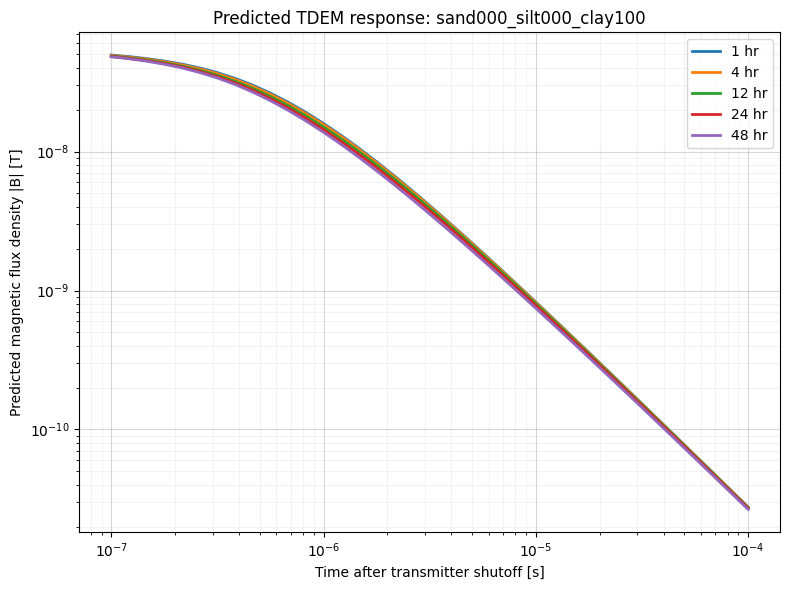

In [289]:
plot_tem_response(
    tem_response_matrices=tem_response_matrices,
    scenario_name="sand000_silt000_clay100",      ### edit scenario you want to see 
    time_min=1e-7,
    time_max=1e-4
)

# CLUSTERING INITAL Development 6/25/26

### 8. Cluster TDEM Responses
#### Comparison of early and late TDEM responses

each soil is represented by two TDEM decay curves from earliest and latest timesteps. Compared using log10 response due to amplitudes spanning several orders of magnitude. 

In [290]:
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist, squareform

In [291]:
# Compare the first and last modeled drainage states.
early_drainage_time = min(times)
late_drainage_time = max(times)

# Use the same receiver-time window used in the TDEM plot above.
comparison_time_min = 1e-7
comparison_time_max = 1e-4

print(f"Early drainage profile: {early_drainage_time} hr")
print(f"Late drainage profile: {late_drainage_time} hr")

Early drainage profile: 1 hr
Late drainage profile: 48 hr


### 8.1 Overlay early/late time responses for all soils

C:\Users\natal\AppData\Local\Temp\ipykernel_36444\427068689.py:48: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


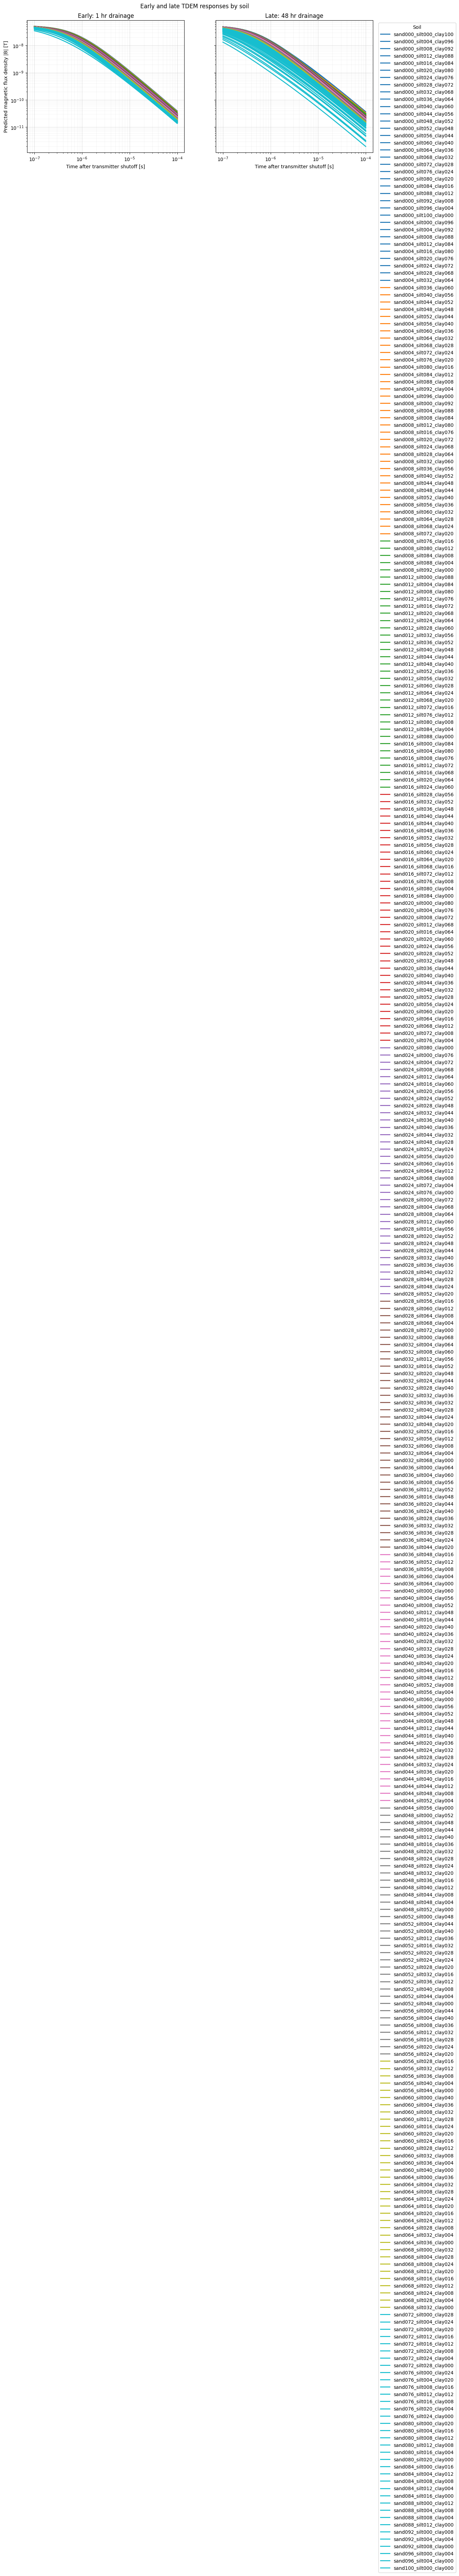

In [292]:
def plot_early_late_responses(
    tem_response_matrices,
    early_time,
    late_time,
    time_min=None,
    time_max=None
):
    """Plot all scenarios at the selected early and late drainage times."""

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
    colors = plt.cm.tab10(np.linspace(0, 1, len(tem_response_matrices)))

    for color, (scenario_name, response_matrix) in zip(
        colors, tem_response_matrices.items()
    ):
        time_mask = np.ones(len(response_matrix), dtype=bool)

        if time_min is not None:
            time_mask &= response_matrix.index.to_numpy() >= time_min
        if time_max is not None:
            time_mask &= response_matrix.index.to_numpy() <= time_max

        visible_times = response_matrix.index.to_numpy()[time_mask]

        for axis, drainage_time, label in zip(
            axes,
            [early_time, late_time],
            ["Early", "Late"]
        ):
            response = np.abs(
                response_matrix.loc[time_mask, drainage_time].to_numpy(dtype=float)
            )
            axis.loglog(
                visible_times,
                response,
                color=color,
                linewidth=2,
                label=scenario_name
            )
            axis.set_title(f"{label}: {drainage_time} hr drainage")
            axis.set_xlabel("Time after transmitter shutoff [s]")
            axis.grid(True, which="major", alpha=0.4)
            axis.grid(True, which="minor", alpha=0.12)

    axes[0].set_ylabel("Predicted magnetic flux density |B| [T]")
    axes[1].legend(title="Soil", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.suptitle("Early and late TDEM responses by soil")
    fig.tight_layout()
    plt.show()


plot_early_late_responses(
    tem_response_matrices=tem_response_matrices,
    early_time=early_drainage_time,
    late_time=late_drainage_time,
    time_min=comparison_time_min,
    time_max=comparison_time_max
)


### 8.15 Check to see if comparison order matters

In [293]:
#from sklearn.cluster import KMeans
#from sklearn.metrics import silhouette_score


def build_soil_vectors(order="early_late"):
    """
    Build one response vector per soil using either:
    - early_late: [early response, late response]
    - late_early: [late response, early response]
    """

    soil_names = []
    vectors = []

    for soil_name, response_matrix in tem_response_matrices.items():

        early_response = response_matrix[early_drainage_time][comparison_mask]
        late_response = response_matrix[late_drainage_time][comparison_mask]

        early_log = np.log10(np.abs(early_response))
        late_log = np.log10(np.abs(late_response))

        if order == "early_late":
            vector = np.concatenate([early_log, late_log])

        elif order == "late_early":
            vector = np.concatenate([late_log, early_log])

        else:
            raise ValueError("order must be 'early_late' or 'late_early'")

        soil_names.append(soil_name)
        vectors.append(vector)

    return soil_names, np.vstack(vectors)

In [294]:
def build_early_late_feature_table(
    tem_response_matrices,
    early_time,
    late_time,
    time_min=None,
    time_max=None,
    response_floor=1e-30,
    order="early_late"
):
    """
    Return one log10 response vector per soil.

    order="early_late" builds:
        [early response, late response]

    order="late_early" builds:
        [late response, early response]
    """

    feature_rows = {}
    feature_columns = None

    for scenario_name, response_matrix in tem_response_matrices.items():

        time_mask = np.ones(len(response_matrix), dtype=bool)

        if time_min is not None:
            time_mask &= response_matrix.index.to_numpy() >= time_min
        if time_max is not None:
            time_mask &= response_matrix.index.to_numpy() <= time_max

        selected_tem_times = response_matrix.index.to_numpy()[time_mask]

        early_response = np.abs(
            response_matrix.loc[time_mask, early_time].to_numpy(dtype=float)
        )
        late_response = np.abs(
            response_matrix.loc[time_mask, late_time].to_numpy(dtype=float)
        )

        early_log_response = np.log10(np.maximum(early_response, response_floor))
        late_log_response = np.log10(np.maximum(late_response, response_floor))

        if order == "early_late":
            feature_vector = np.concatenate([
                early_log_response,
                late_log_response
            ])

            column_labels = (
                [f"early_{tem_time:.3e}_s" for tem_time in selected_tem_times]
                +
                [f"late_{tem_time:.3e}_s" for tem_time in selected_tem_times]
            )

        elif order == "late_early":
            feature_vector = np.concatenate([
                late_log_response,
                early_log_response
            ])

            column_labels = (
                [f"late_{tem_time:.3e}_s" for tem_time in selected_tem_times]
                +
                [f"early_{tem_time:.3e}_s" for tem_time in selected_tem_times]
            )

        else:
            raise ValueError("order must be 'early_late' or 'late_early'")

        feature_rows[scenario_name] = feature_vector

        if feature_columns is None:
            feature_columns = column_labels

    return pd.DataFrame.from_dict(
        feature_rows,
        orient="index",
        columns=feature_columns
    )

In [295]:

clustering_features_EL = build_early_late_feature_table(
    tem_response_matrices=tem_response_matrices,
    early_time=early_drainage_time,
    late_time=late_drainage_time,
    time_min=comparison_time_min,
    time_max=comparison_time_max,
    order="early_late"
)

clustering_features_LE = build_early_late_feature_table(
    tem_response_matrices=tem_response_matrices,
    early_time=early_drainage_time,
    late_time=late_drainage_time,
    time_min=comparison_time_min,
    time_max=comparison_time_max,
    order="late_early"
)

display(clustering_features_EL.iloc[:, :5])
#display(clustering_features_LE.iloc[:, :5])

clustering_features = clustering_features_EL  ## OR  clustering_features_LE

,early_1.000e-07_s,early_1.212e-07_s,early_1.468e-07_s,early_1.778e-07_s,early_2.154e-07_s
sand000_silt000_clay100,-7.305340,-7.316707,-7.330837,-7.348481,-7.370554
sand000_silt004_clay096,-7.303863,-7.314884,-7.328576,-7.345665,-7.367046
sand000_silt008_clay092,-7.302755,-7.313514,-7.326874,-7.343542,-7.364395
sand000_silt012_clay088,-7.301953,-7.312521,-7.325638,-7.341997,-7.362463
sand000_silt016_clay084,-7.301382,-7.311813,-7.324758,-7.340898,-7.361087
...,...,...,...,...,...
sand092_silt004_clay004,-7.382878,-7.407034,-7.435762,-7.469731,-7.509545
sand092_silt008_clay000,-7.382900,-7.406522,-7.434538,-7.467606,-7.506330
sand096_silt000_clay004,-7.414966,-7.443884,-7.477492,-7.516201,-7.560348
sand096_silt004_clay000,-7.417271,-7.445812,-7.478854,-7.516792,-7.559962


### 8.3 Calculate similarity

the log-RMSE across all selected reciever times and both drainage timesteps. A smaller distance indicates less distinguishable change between the TDEM responses

In [296]:
# Scaling by sqrt(number of features) makes Euclidean distance equal
# to RMSE in log10 response units.
"""rmse_scaled_features = (
    clustering_features.to_numpy(dtype=float)
    / np.sqrt(clustering_features.shape[1])
)

condensed_distances = pdist(rmse_scaled_features, metric="euclidean")
distance_matrix = pd.DataFrame(
    squareform(condensed_distances),
    index=clustering_features.index,
    columns=clustering_features.index
)

fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(distance_matrix, cmap="viridis_r")
ax.set_xticks(range(len(distance_matrix.columns)))
ax.set_xticklabels(distance_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(distance_matrix.index)))
ax.set_yticklabels(distance_matrix.index)

for row in range(len(distance_matrix.index)):
    for column in range(len(distance_matrix.columns)):
        ax.text(
            column,
            row,
            f"{distance_matrix.iloc[row, column]:.3f}",
            ha="center",
            va="center",
            fontsize=8,
            color=(
                "white"
                if distance_matrix.iloc[row, column] > distance_matrix.to_numpy().max() / 2
                else "black"
            )
        )

ax.set_title("Pairwise TDEM distance (log10 RMSE; lower is more similar)")
fig.colorbar(image, ax=ax, label="Log10 RMSE [decades]")
fig.tight_layout()
plt.show()

# Rank the unique soil pairs from most to least similar.
pairwise_rows = []
soil_names = list(distance_matrix.index)

for first_index, first_soil in enumerate(soil_names):
    for second_soil in soil_names[first_index + 1:]:
        log_rmse = distance_matrix.loc[first_soil, second_soil]
        pairwise_rows.append({
            "soil_1": first_soil,
            "soil_2": second_soil,
            "log10_rmse_decades": log_rmse,
            "typical_amplitude_factor": 10**log_rmse
        })

closest_soil_pairs = (
    pd.DataFrame(pairwise_rows)
    .sort_values("log10_rmse_decades")
    .reset_index(drop=True)
)

display(closest_soil_pairs)
"""

'rmse_scaled_features = (\n    clustering_features.to_numpy(dtype=float)\n    / np.sqrt(clustering_features.shape[1])\n)\n\ncondensed_distances = pdist(rmse_scaled_features, metric="euclidean")\ndistance_matrix = pd.DataFrame(\n    squareform(condensed_distances),\n    index=clustering_features.index,\n    columns=clustering_features.index\n)\n\nfig, ax = plt.subplots(figsize=(8, 7))\nimage = ax.imshow(distance_matrix, cmap="viridis_r")\nax.set_xticks(range(len(distance_matrix.columns)))\nax.set_xticklabels(distance_matrix.columns, rotation=45, ha="right")\nax.set_yticks(range(len(distance_matrix.index)))\nax.set_yticklabels(distance_matrix.index)\n\nfor row in range(len(distance_matrix.index)):\n    for column in range(len(distance_matrix.columns)):\n        ax.text(\n            column,\n            row,\n            f"{distance_matrix.iloc[row, column]:.3f}",\n            ha="center",\n            va="center",\n            fontsize=8,\n            color=(\n                "white"\n 

### 8.4 TDEM Response Clustering (K-means)
#### Looks at soil vectors and determines which have similar early/later response patterns. 
K-means does not know anything about sand, loam, or clay. It only sees numerical response vectors and groups the most similar vectors together.

In [297]:
k = 3  # change to desired number

X_EL = clustering_features_EL.to_numpy(dtype=float)
X_LE = clustering_features_LE.to_numpy(dtype=float)

kmeans_EL = KMeans(n_clusters=k, random_state=0, n_init=20)
kmeans_LE = KMeans(n_clusters=k, random_state=0, n_init=20)

labels_EL = kmeans_EL.fit_predict(X_EL)
labels_LE = kmeans_LE.fit_predict(X_LE)

kmeans_order_comparison = pd.DataFrame({
    "soil": clustering_features_EL.index,
    "cluster_early_late": labels_EL,
    "cluster_late_early": labels_LE
})

display(kmeans_order_comparison)

print("Early-late inertia:", kmeans_EL.inertia_)
print("Late-early inertia:", kmeans_LE.inertia_)

if len(set(labels_EL)) > 1:
    print("Early-late silhouette:", silhouette_score(X_EL, labels_EL))

if len(set(labels_LE)) > 1:
    print("Late-early silhouette:", silhouette_score(X_LE, labels_LE))

centroids = find_centroids(
    feature_df=clustering_features_EL,
    kmeans_model=kmeans_EL,
    labels=labels_EL
)

display(centroids)

,soil,cluster_early_late,cluster_late_early
0,sand000_silt000_clay100,1,1
1,sand000_silt004_clay096,1,1
2,sand000_silt008_clay092,1,1
3,sand000_silt012_clay088,1,1
4,sand000_silt016_clay084,1,1
...,...,...,...
346,sand092_silt004_clay004,2,2
347,sand092_silt008_clay000,2,2
348,sand096_silt000_clay004,2,2
349,sand096_silt004_clay000,2,2


Early-late inertia: 84.32327913415416
Late-early inertia: 84.32327913415416
Early-late silhouette: 0.5786970814144353
Late-early silhouette: 0.5786970814148077


,cluster,representative_soil,distance_to_centroid,n_soils_in_cluster
0,0,sand040_silt048_clay012,0.067901,148
1,1,sand020_silt028_clay052,0.017099,191
2,2,sand092_silt000_clay008,0.176646,12


Create Dataframe with soil names and cluster labels
 *Used for later plotting of soils with cluster groups

In [298]:
all_soils_cluster_df = kmeans_order_comparison.copy()

all_soils_cluster_df["cluster"] = all_soils_cluster_df["cluster_early_late"]

display(all_soils_cluster_df.head())

,soil,cluster_early_late,cluster_late_early,cluster
0,sand000_silt000_clay100,1,1,1
1,sand000_silt004_clay096,1,1,1
2,sand000_silt008_clay092,1,1,1
3,sand000_silt012_clay088,1,1,1
4,sand000_silt016_clay084,1,1,1


### 8.5 Select representative soils / centriods of the clusters

In [299]:
def find_centroids(feature_df, kmeans_model, labels):
    """
    Find the actual soil closest to each K-means centroid.

    this selects the modeled soil nearest to the centroid in the clustering feature space.
    """

    X = feature_df.to_numpy(dtype=float)

    representative_rows = []

    for cluster_id in sorted(np.unique(labels)):

        cluster_member_positions = np.where(labels == cluster_id)[0]

        cluster_centroid = kmeans_model.cluster_centers_[cluster_id]

        distances_to_centroid = np.linalg.norm(
            X[cluster_member_positions] - cluster_centroid,
            axis=1
        )

        closest_member_position = cluster_member_positions[
            np.argmin(distances_to_centroid)
        ]

        representative_soil = feature_df.index[closest_member_position]

        representative_rows.append({
            "cluster": cluster_id,
            "representative_soil": representative_soil,
            "distance_to_centroid": distances_to_centroid.min(),
            "n_soils_in_cluster": len(cluster_member_positions)
        })

    return pd.DataFrame(representative_rows)

In [300]:
centroids = find_centroids(
    feature_df=clustering_features_EL,
    kmeans_model=kmeans_EL,
    labels=labels_EL
)

display(centroids)

,cluster,representative_soil,distance_to_centroid,n_soils_in_cluster
0,0,sand040_silt048_clay012,0.067901,148
1,1,sand020_silt028_clay052,0.017099,191
2,2,sand092_silt000_clay008,0.176646,12


### 8.? Use the Elbow Method to Check reasonable number of Clusters

In [301]:
inertias = []
silhouette_scores = []
k_values = range(1, 11)

X = clustering_features_EL.to_numpy(dtype=float)

for k_test in k_values:
    kmeans = KMeans(
        n_clusters=k_test,
        random_state=0,
        n_init=20
    )

    labels = kmeans.fit_predict(X)
    inertias.append(kmeans.inertia_)

    if k_test > 1:
        silhouette_scores.append(silhouette_score(X, labels))
    else:
        silhouette_scores.append(np.nan)

elbow_df = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

display(elbow_df)

,k,inertia,silhouette_score
0,1,388.456209,NaN
1,2,171.972359,0.560030
2,3,84.323279,0.578697
3,4,55.964447,0.489171
4,5,42.149333,0.488350
5,6,33.702598,0.435785
6,7,28.475131,0.428474
7,8,23.784051,0.446922
8,9,19.937319,0.420788
9,10,17.529176,0.401052


### Elbow plot based on TDEM -response clustering 

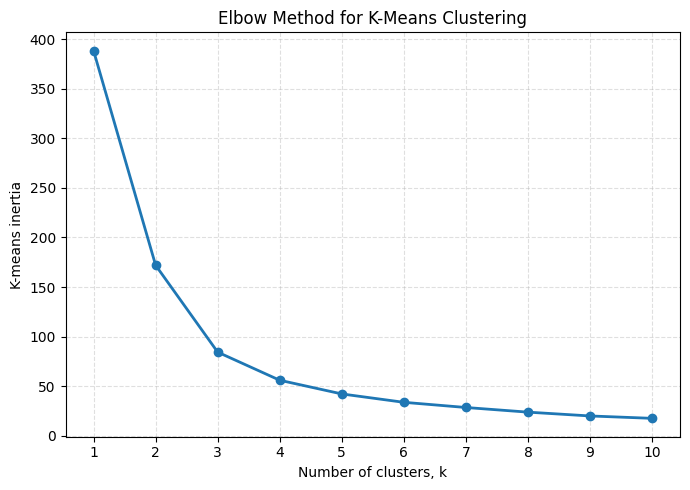

In [302]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    elbow_df["k"],
    elbow_df["inertia"],
    marker="o",
    linewidth=2
)

ax.set_xlabel("Number of clusters, k")
ax.set_ylabel("K-means inertia")
ax.set_title("Elbow Method for K-Means Clustering")
ax.set_xticks(list(k_values))
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Sand Clay Plot for Clustering

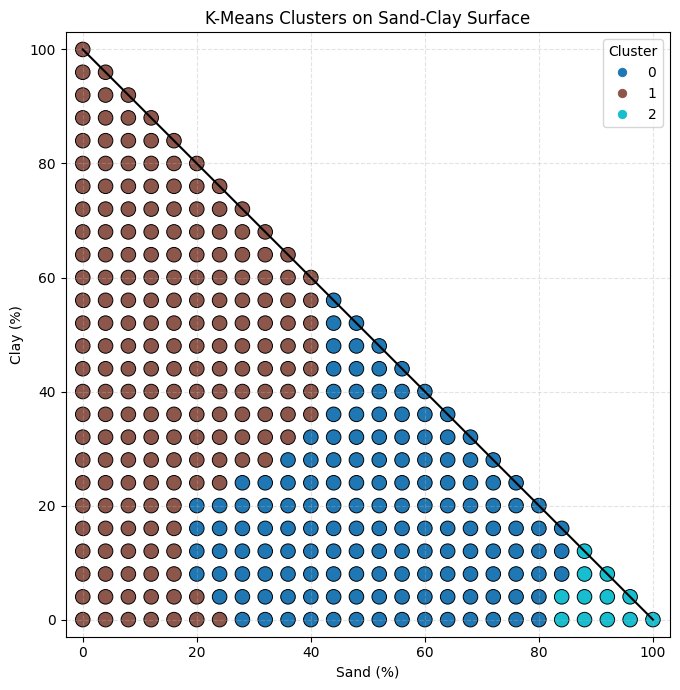

In [303]:
cluster_sand_clay_df = kmeans_order_comparison.copy()

texture_parts = cluster_sand_clay_df["soil"].str.extract(
    r"sand(?P<sand>\d+)_silt(?P<silt>\d+)_clay(?P<clay>\d+)"
)

cluster_sand_clay_df[["sand", "silt", "clay"]] = texture_parts.astype(float)
cluster_sand_clay_df["cluster"] = cluster_sand_clay_df["cluster_early_late"]

fig, ax = plt.subplots(figsize=(8, 7))

scatter = ax.scatter(
    cluster_sand_clay_df["sand"],
    cluster_sand_clay_df["clay"],
    c=cluster_sand_clay_df["cluster"],
    cmap="tab10",
    s=110,
    edgecolor="black",
    linewidth=0.7
)

ax.plot([0, 100], [100, 0], color="black", linewidth=1.5)

ax.set_xlim(-3, 103)
ax.set_ylim(-3, 103)
ax.set_aspect("equal")

ax.set_xlabel("Sand (%)")
ax.set_ylabel("Clay (%)")
ax.set_title("K-Means Clusters on Sand-Clay Surface")

ax.grid(True, linestyle="--", alpha=0.35)

ax.legend(
    *scatter.legend_elements(),
    title="Cluster",
    loc="upper right"
)

plt.tight_layout()
plt.show()

### Plot Cluster Results on the Soil Texture Triangle

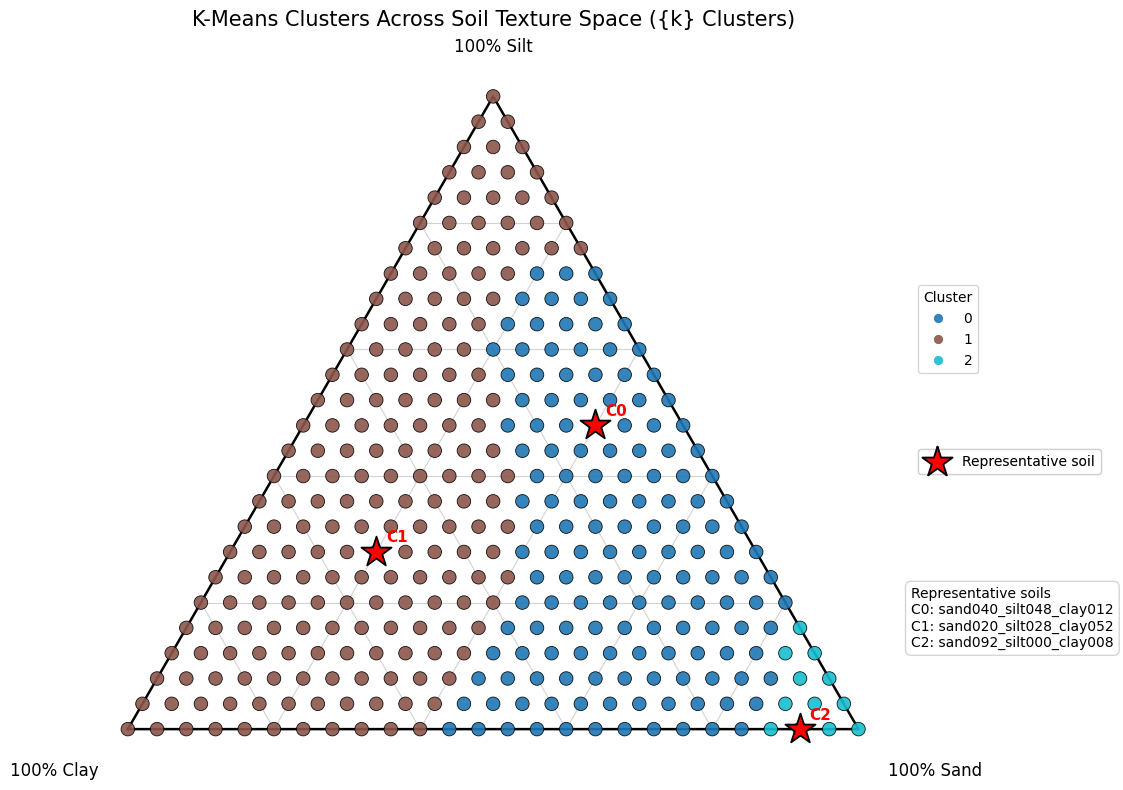

In [304]:
cluster_plot_df = kmeans_order_comparison.copy()

texture_parts = cluster_plot_df["soil"].str.extract(
    r"sand(?P<sand>\d+)_silt(?P<silt>\d+)_clay(?P<clay>\d+)"
)

cluster_plot_df[["sand", "silt", "clay"]] = texture_parts.astype(float)
cluster_plot_df["cluster"] = cluster_plot_df["cluster_early_late"]

# Ternary coordinates:
# left corner = clay, right corner = sand, top corner = silt
sand = cluster_plot_df["sand"] / 100
silt = cluster_plot_df["silt"] / 100

cluster_plot_df["ternary_x"] = sand + 0.5 * silt
cluster_plot_df["ternary_y"] = (np.sqrt(3) / 2) * silt

representative_plot_df = cluster_plot_df[
    cluster_plot_df["soil"].isin(centroids["representative_soil"])
].copy()

fig, ax = plt.subplots(figsize=(10.5, 8))

# Draw triangle boundary
triangle_x = [0, 1, 0.5, 0]
triangle_y = [0, 0, np.sqrt(3) / 2, 0]
ax.plot(triangle_x, triangle_y, color="black", linewidth=1.8)

# Add light gridlines every 20%
for p in np.arange(0.2, 1.0, 0.2):
    # constant silt
    ax.plot(
        [0.5 * p, 1 - 0.5 * p],
        [(np.sqrt(3) / 2) * p, (np.sqrt(3) / 2) * p],
        color="lightgray",
        linewidth=0.8,
        zorder=0
    )

    # constant sand
    ax.plot(
        [p, 0.5 + 0.5 * p],
        [0, (np.sqrt(3) / 2) * (1 - p)],
        color="lightgray",
        linewidth=0.8,
        zorder=0
    )

    # constant clay
    ax.plot(
        [1 - p, 0.5 * (1 - p)],
        [0, (np.sqrt(3) / 2) * (1 - p)],
        color="lightgray",
        linewidth=0.8,
        zorder=0
    )

# All soils colored by cluster
scatter = ax.scatter(
    cluster_plot_df["ternary_x"],
    cluster_plot_df["ternary_y"],
    c=cluster_plot_df["cluster"],
    cmap="tab10",
    s=95,
    edgecolor="black",
    linewidth=0.6,
    alpha=0.9,
    zorder=3
)

# Representative soils closest to K-means centroids
representative_scatter = ax.scatter(
    representative_plot_df["ternary_x"],
    representative_plot_df["ternary_y"],
    marker="*",
    s=520,
    facecolor="red",
    edgecolor="black",
    linewidth=1.3,
    zorder=5,
    label="Representative soil"
)

# Short labels inside the plot
for _, row in representative_plot_df.iterrows():
    ax.annotate(
        f"C{int(row['cluster'])}",
        (row["ternary_x"], row["ternary_y"]),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
        color="red"
    )

# Corner labels
ax.text(-0.04, -0.045, "100% Clay", ha="right", va="top", fontsize=12)
ax.text(1.04, -0.045, "100% Sand", ha="left", va="top", fontsize=12)
ax.text(0.5, np.sqrt(3) / 2 + 0.055, "100% Silt", ha="center", va="bottom", fontsize=12)

ax.set_title(
    "K-Means Clusters Across Soil Texture Space ({k} Clusters)",
    fontsize=15,
    pad=28
)

# Cluster color legend
cluster_legend = ax.legend(
    *scatter.legend_elements(),
    title="Cluster",
    loc="center left",
    bbox_to_anchor=(1.02, 0.62),
    frameon=True
)

ax.add_artist(cluster_legend)

# Representative marker legend
representative_legend = ax.legend(
    handles=[representative_scatter],
    labels=["Representative soil"],
    loc="center left",
    bbox_to_anchor=(1.02, 0.43),
    frameon=True
)

ax.add_artist(representative_legend)

# Side label box for representative soils
representative_label_lines = []

for _, row in representative_plot_df.sort_values("cluster").iterrows():
    representative_label_lines.append(
        f"C{int(row['cluster'])}: {row['soil']}"
    )

representative_label_text = "Representative soils\n" + "\n".join(representative_label_lines)

ax.text(
    1.02,
    0.25,
    representative_label_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="lightgray",
        alpha=0.95
    )
)

ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()
plt.show()

### 9. Data Analysis and Processing 

### 9.1 Hydraulic Functions - define van Genuchten relationships for plotting
#### Theta(psi)
#### K(psi)

In [305]:
def theta_vg_pressure_head(psi_cm, theta_r, theta_s, alpha, vg_n):
    """Water content from the van Genuchten retention curve."""
    psi_cm = np.asarray(psi_cm, dtype=float)
    m = 1 - (1 / vg_n)

    theta = np.full_like(psi_cm, theta_s, dtype=float)
    unsat = psi_cm < 0
    Se = (1 + (alpha * np.abs(psi_cm[unsat])) ** vg_n) ** (-m)
    theta[unsat] = theta_r + Se * (theta_s - theta_r)

    return theta


def k_vg_pressure_head(psi_cm, theta_r, theta_s, alpha, vg_n, Ks, l=0.5):
    """Hydraulic conductivity from the van Genuchten-Mualem K function."""
    theta = theta_vg_pressure_head(
        psi_cm=psi_cm,
        theta_r=theta_r,
        theta_s=theta_s,
        alpha=alpha,
        vg_n=vg_n
    )

    Se = (theta - theta_r) / (theta_s - theta_r)
    Se = np.clip(Se, 1e-8, 1.0)
    Kr = kr_vg_mualem(Se, vg_n=vg_n, l=l)

    return Ks * Kr
### gives absolute hydraulic conductivity

### Build feature tables for comparitive clustering.

In [306]:
pressure_head_cm = np.linspace(0, -300, 10)

def build_hydraulic_feature_tables(scenarios_to_run, pressure_head_cm):
    """
    Build advisor-requested clustering feature tables:
    1. theta(psi)
    2. K(psi)
    3. theta(psi) and K(psi)
    4. van Genuchten parameters
    """

    theta_rows = {}
    k_rows = {}
    vg_rows = {}

    for scenario_name, params in scenarios_to_run.items():

        theta_curve = theta_vg_pressure_head(
            psi_cm=pressure_head_cm,
            theta_r=params["theta_r"],
            theta_s=params["theta_s"],
            alpha=params["alpha"],
            vg_n=params["vg_n"]
        )

        k_curve = k_vg_pressure_head(
            psi_cm=pressure_head_cm,
            theta_r=params["theta_r"],
            theta_s=params["theta_s"],
            alpha=params["alpha"],
            vg_n=params["vg_n"],
            Ks=params["Ks"],
            l=params.get("l", 0.5)
        )

        theta_rows[scenario_name] = theta_curve

        # K spans orders of magnitude, so cluster log10(K), not raw K.
        k_rows[scenario_name] = np.log10(np.maximum(k_curve, 1e-30))

        vg_rows[scenario_name] = {
            "theta_r": params["theta_r"],
            "theta_s": params["theta_s"],
            "log10_alpha": np.log10(params["alpha"]),
            "vg_n": params["vg_n"],
            "log10_Ks": np.log10(params["Ks"])
        }

    theta_columns = [f"theta_psi_{psi:.1f}_cm" for psi in pressure_head_cm]
    k_columns = [f"log10_K_psi_{psi:.1f}_cm" for psi in pressure_head_cm]

    theta_feature_df = pd.DataFrame.from_dict(
        theta_rows,
        orient="index",
        columns=theta_columns
    )

    k_feature_df = pd.DataFrame.from_dict(
        k_rows,
        orient="index",
        columns=k_columns
    )

    theta_k_feature_df = pd.concat(
        [theta_feature_df, k_feature_df],
        axis=1
    )

    vg_feature_df = pd.DataFrame.from_dict(
        vg_rows,
        orient="index"
    )

    return {
        "theta_psi": theta_feature_df,
        "K_psi": k_feature_df,
        "theta_and_K_psi": theta_k_feature_df,
        "vg_params": vg_feature_df
    }


hydraulic_feature_tables = build_hydraulic_feature_tables(
    scenarios_to_run=scenarios_to_run,
    pressure_head_cm=pressure_head_cm
)

display(hydraulic_feature_tables["theta_psi"].head())
display(hydraulic_feature_tables["K_psi"].head())
display(hydraulic_feature_tables["vg_params"].head())

,theta_psi_0.0_cm,theta_psi_-33.3_cm,theta_psi_-66.7_cm,theta_psi_-100.0_cm,theta_psi_-133.3_cm,theta_psi_-166.7_cm,theta_psi_-200.0_cm,theta_psi_-233.3_cm,theta_psi_-266.7_cm,theta_psi_-300.0_cm
sand000_silt000_clay100,0.4968,0.476959,0.460820,0.448379,0.438443,0.430251,0.423322,0.417344,0.412103,0.407449
sand000_silt004_clay096,0.5058,0.484201,0.467139,0.454187,0.443936,0.435533,0.428453,0.422363,0.417034,0.412310
sand000_silt008_clay092,0.5130,0.489330,0.471034,0.457330,0.446573,0.437802,0.430443,0.424129,0.418619,0.413742
sand000_silt012_clay088,0.5185,0.492794,0.473124,0.458519,0.447124,0.437874,0.430136,0.423515,0.417748,0.412652
sand000_silt016_clay084,0.5225,0.494815,0.473676,0.458073,0.445956,0.436153,0.427977,0.420997,0.414929,0.409576


,log10_K_psi_0.0_cm,log10_K_psi_-33.3_cm,log10_K_psi_-66.7_cm,log10_K_psi_-100.0_cm,log10_K_psi_-133.3_cm,log10_K_psi_-166.7_cm,log10_K_psi_-200.0_cm,log10_K_psi_-233.3_cm,log10_K_psi_-266.7_cm,log10_K_psi_-300.0_cm
sand000_silt000_clay100,-0.113274,-1.832200,-2.278884,-2.587384,-2.824947,-3.018439,-3.181728,-3.322985,-3.447448,-3.558681
sand000_silt004_clay096,-0.125663,-1.903343,-2.361066,-2.675042,-2.915757,-3.111233,-3.275846,-3.418024,-3.543146,-3.654862
sand000_silt008_clay092,-0.129791,-1.937386,-2.405803,-2.725592,-2.969968,-3.167968,-3.334435,-3.478038,-3.604294,-3.716936
sand000_silt012_clay088,-0.131993,-1.936671,-2.413444,-2.738325,-2.986196,-3.186789,-3.355283,-3.500533,-3.628167,-3.741988
sand000_silt016_clay084,-0.136182,-1.917742,-2.401368,-2.730925,-2.982230,-3.185495,-3.356159,-3.503224,-3.632414,-3.747593


,theta_r,theta_s,log10_alpha,vg_n,log10_Ks
sand000_silt000_clay100,0.1095,0.4968,-1.798603,1.1548,-0.113274
sand000_silt004_clay096,0.1081,0.5058,-1.764472,1.1520,-0.125663
sand000_silt008_clay092,0.1074,0.5130,-1.735182,1.1541,-0.129791
sand000_silt012_clay088,0.1074,0.5185,-1.716699,1.1603,-0.131993
sand000_silt016_clay084,0.1076,0.5225,-1.705534,1.1692,-0.136182


### Repeat of elbow plot and k-means clustering for all four feature sets

In [ ]:
def run_kmeans_feature_clustering(feature_df, k, max_k=10):
    """
    Standardize a feature table, run K-means clustering, calculate elbow table,
    and identify representative centroid soils.
    """

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(feature_df.to_numpy(dtype=float))

    scaled_feature_df = pd.DataFrame(
        X_scaled,
        index=feature_df.index,
        columns=feature_df.columns
    )

    kmeans = KMeans(n_clusters=k, random_state=0, n_init=20)
    labels = kmeans.fit_predict(X_scaled)

    all_soils_cluster_df = pd.DataFrame({
        "soil": feature_df.index,
        "cluster": labels
    })

    centroids = find_centroids(
        feature_df=scaled_feature_df,
        kmeans_model=kmeans,
        labels=labels
    )

    inertias = []
    silhouette_scores = []

    n_samples = feature_df.shape[0]
    k_values = range(1, min(max_k, n_samples) + 1)

    for k_test in k_values:
        test_kmeans = KMeans(
            n_clusters=k_test,
            random_state=0,
            n_init=20
        )

        test_labels = test_kmeans.fit_predict(X_scaled)
        inertias.append(test_kmeans.inertia_)

        if 1 < k_test < n_samples:
            silhouette_scores.append(silhouette_score(X_scaled, test_labels))
        else:
            silhouette_scores.append(np.nan)

    elbow_df = pd.DataFrame({
        "k": list(k_values),
        "inertia": inertias,
        "silhouette_score": silhouette_scores
    })

    return {
        "feature_df": feature_df,
        "scaled_feature_df": scaled_feature_df,
        "kmeans": kmeans,
        "labels": labels,
        "all_soils_cluster_df": all_soils_cluster_df,
        "centroids": centroids,
        "elbow_df": elbow_df
    }


k = 3  # change to 3 or 5 depending on the version you want

hydraulic_clustering_results = {}

for feature_name, feature_df in hydraulic_feature_tables.items():

    hydraulic_clustering_results[feature_name] = run_kmeans_feature_clustering(
        feature_df=feature_df,
        k=k,
        max_k=10
    )

    """print(f"\nFeature set: {feature_name}")
    display(hydraulic_clustering_results[feature_name]["all_soils_cluster_df"])
    display(hydraulic_clustering_results[feature_name]["centroids"])
    display(hydraulic_clustering_results[feature_name]["elbow_df"])"""


Feature set: theta_psi


,soil,cluster
0,sand000_silt000_clay100,0
1,sand000_silt004_clay096,0
2,sand000_silt008_clay092,0
3,sand000_silt012_clay088,0
4,sand000_silt016_clay084,0
...,...,...
346,sand092_silt004_clay004,1
347,sand092_silt008_clay000,1
348,sand096_silt000_clay004,1
349,sand096_silt004_clay000,1


,cluster,representative_soil,distance_to_centroid,n_soils_in_cluster
0,0,sand016_silt032_clay052,0.232921,206
1,1,sand084_silt008_clay008,0.296467,31
2,2,sand048_silt024_clay028,0.078974,114


,k,inertia,silhouette_score
0,1,3510.000000,NaN
1,2,1226.635370,0.588990
2,3,658.693747,0.548857
3,4,438.402157,0.446138
4,5,310.134315,0.450933
5,6,239.517601,0.431860
6,7,193.915787,0.409965
7,8,163.930053,0.413748
8,9,142.366852,0.398221
9,10,126.687038,0.374671



Feature set: K_psi


...

,k,inertia,silhouette_score
0,1,7020.000000,NaN
1,2,4260.176012,0.389794
2,3,2438.530752,0.444126
3,4,1715.105511,0.447797
4,5,1384.625525,0.424070
5,6,1094.811946,0.402593
6,7,945.549837,0.392837
7,8,814.786927,0.374453
8,9,722.446314,0.362065
9,10,637.701663,0.376186



Feature set: vg_params


,soil,cluster
0,sand000_silt000_clay100,0
1,sand000_silt004_clay096,0
2,sand000_silt008_clay092,0
3,sand000_silt012_clay088,0
4,sand000_silt016_clay084,0
...,...,...
346,sand092_silt004_clay004,1
347,sand092_silt008_clay000,1
348,sand096_silt000_clay004,1
349,sand096_silt004_clay000,1


,cluster,representative_soil,distance_to_centroid,n_soils_in_cluster
0,0,sand028_silt024_clay048,0.146391,191
1,1,sand080_silt008_clay012,0.522450,67
2,2,sand012_silt076_clay012,0.489829,93


,k,inertia,silhouette_score
0,1,1755.000000,NaN
1,2,1152.732164,0.377667
2,3,852.216703,0.396558
3,4,605.771965,0.416094
4,5,460.567572,0.406288
5,6,355.853084,0.426945
6,7,312.752435,0.410213
7,8,273.018513,0.383703
8,9,241.029902,0.380379
9,10,216.753624,0.376783


### Elbow plot for all methods (to compare)

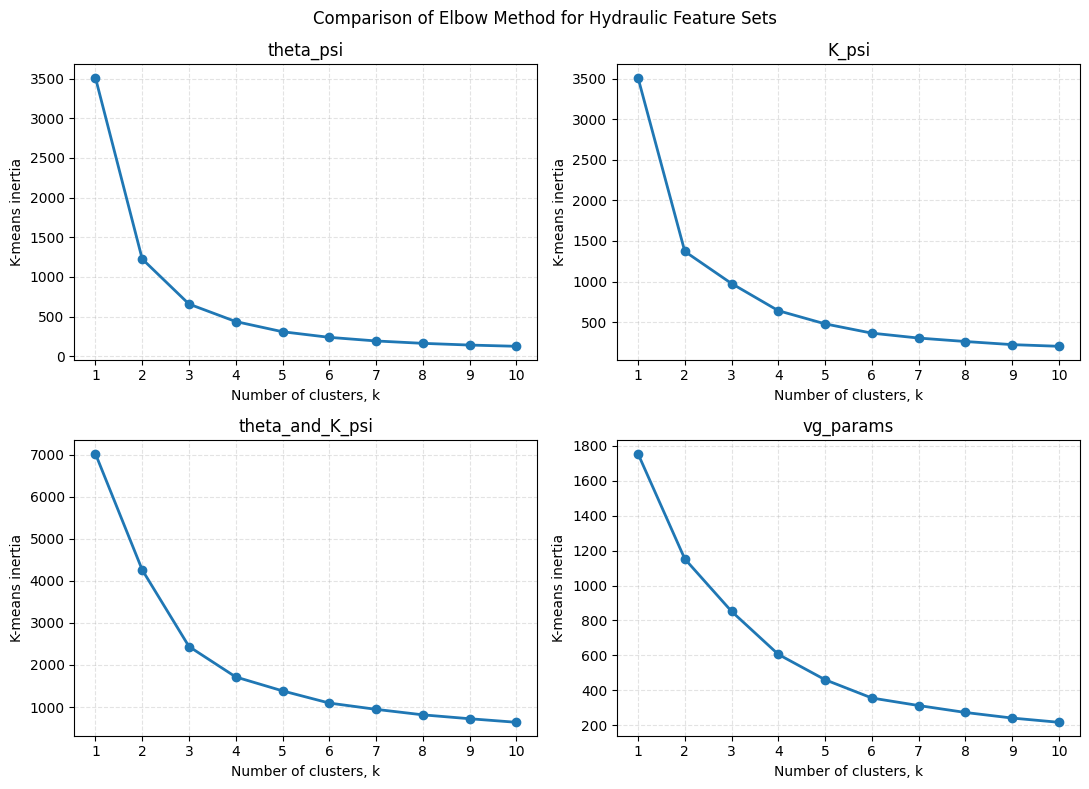

In [313]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=False)

for ax, (feature_name, result) in zip(
    axes.ravel(),
    hydraulic_clustering_results.items()
):
    elbow_df = result["elbow_df"]

    ax.plot(
        elbow_df["k"],
        elbow_df["inertia"],
        marker="o",
        linewidth=2
    )

    ax.set_title(feature_name)
    ax.set_xlabel("Number of clusters, k")
    ax.set_ylabel("K-means inertia")
    ax.set_xticks(elbow_df["k"])
    ax.grid(True, linestyle="--", alpha=0.35)

fig.suptitle("Comparison of Elbow Method for Hydraulic Feature Sets")
plt.tight_layout()
plt.show()

### Use centroids dataframe from the texture-triangle to plot representative soils and associated theta vs psi relationships

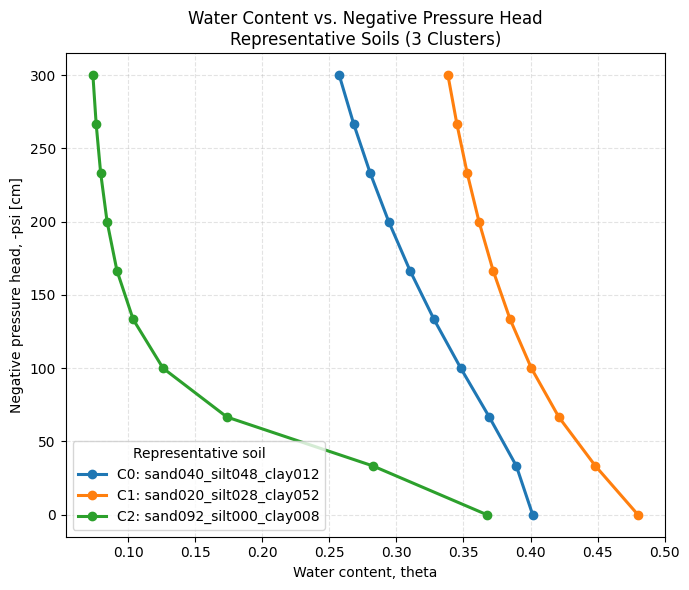

In [308]:
# Given pressure-head values for inital analysis 7/1/26
pressure_head_cm = np.linspace(0, -300, 10)
negative_pressure_head_cm = -pressure_head_cm

fig, ax = plt.subplots(figsize=(7, 6))

for _, row in centroids.sort_values("cluster").iterrows():

    cluster_id = int(row["cluster"])
    scenario_name = row["representative_soil"]

    params = scenarios_to_run[scenario_name]

    theta_curve = theta_vg_pressure_head(
        psi_cm=pressure_head_cm,
        theta_r=params["theta_r"],
        theta_s=params["theta_s"],
        alpha=params["alpha"],
        vg_n=params["vg_n"]
    )

    ax.plot(
        theta_curve,
        negative_pressure_head_cm,
        marker="o",
        linewidth=2.2,
        label=f"C{cluster_id}: {scenario_name}"
    )

ax.set_xlabel("Water content, theta")
ax.set_ylabel("Negative pressure head, -psi [cm]")
ax.set_title(f"Water Content vs. Negative Pressure Head\nRepresentative Soils ({k} Clusters)")

ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(title="Representative soil")

plt.tight_layout()
plt.show()

### Water content vs Psi for all soils (grouped by cluster)

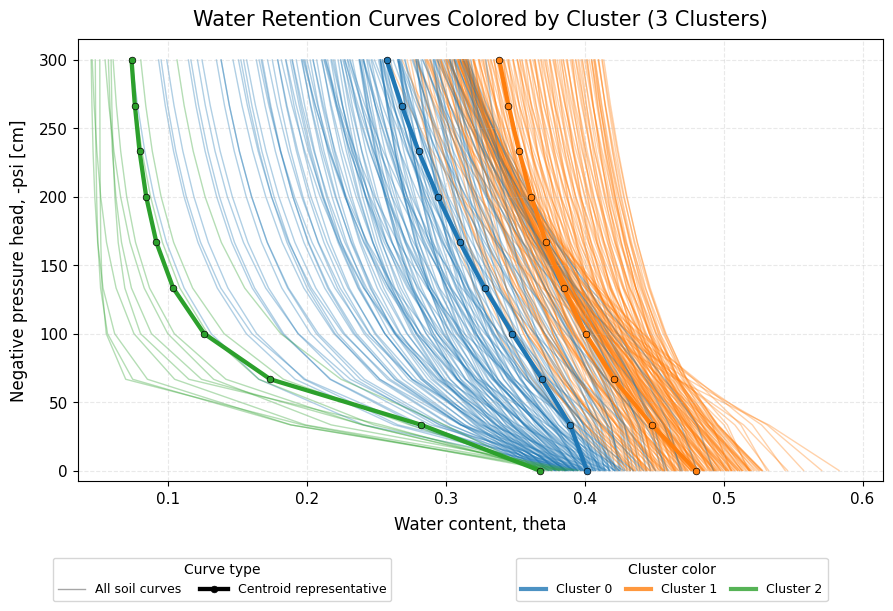

In [309]:
pressure_head_cm = np.linspace(0, -300, 10)
negative_pressure_head_cm = -pressure_head_cm

fig, ax = plt.subplots(figsize=(9, 6.8))

cmap = plt.get_cmap("tab10")

# -------------------------------------------------
# Plot all soils as background cluster-colored curves
# -------------------------------------------------
for _, row in all_soils_cluster_df.iterrows():

    scenario_name = row["soil"]
    cluster_id = int(row["cluster"])
    params = scenarios_to_run[scenario_name]

    theta_curve = theta_vg_pressure_head(
        psi_cm=pressure_head_cm,
        theta_r=params["theta_r"],
        theta_s=params["theta_s"],
        alpha=params["alpha"],
        vg_n=params["vg_n"]
    )

    ax.plot(
        theta_curve,
        negative_pressure_head_cm,
        color=cmap(cluster_id),
        linewidth=1.0,
        alpha=0.35,
        zorder=1
    )

# -------------------------------------------------
# Plot representative centroid soils in bold cluster colors
# -------------------------------------------------
rep_handles = []

for _, row in centroids.sort_values("cluster").iterrows():

    cluster_id = int(row["cluster"])
    scenario_name = row["representative_soil"]
    params = scenarios_to_run[scenario_name]

    theta_curve = theta_vg_pressure_head(
        psi_cm=pressure_head_cm,
        theta_r=params["theta_r"],
        theta_s=params["theta_s"],
        alpha=params["alpha"],
        vg_n=params["vg_n"]
    )

    line, = ax.plot(
        theta_curve,
        negative_pressure_head_cm,
        color=cmap(cluster_id),
        linewidth=3.1,
        alpha=1.0,
        linestyle="-",
        marker="o",
        markersize=4.8,
        markeredgecolor="black",
        markeredgewidth=0.5,
        zorder=5,
        label=f"C{cluster_id} representative"
    )

    rep_handles.append(line)

# -------------------------------------------------
# Axes formatting
# -------------------------------------------------
ax.set_xlabel("Water content, theta", fontsize=12, labelpad=7)
ax.set_ylabel("Negative pressure head, -psi [cm]", fontsize=12, labelpad=8)

ax.set_title(
    f"Water Retention Curves Colored by Cluster ({k} Clusters)",
    fontsize=15,
    pad=10
)

ax.set_xlim(0.035, 0.615)
ax.set_ylim(-8, 315)

ax.grid(True, linestyle="--", alpha=0.28)
ax.tick_params(labelsize=11)

# -------------------------------------------------
# Legend handles
# -------------------------------------------------
cluster_handles = [
    plt.Line2D(
        [0], [0],
        color=cmap(int(cluster_id)),
        linewidth=3,
        alpha=0.8,
        label=f"Cluster {int(cluster_id)}"
    )
    for cluster_id in sorted(all_soils_cluster_df["cluster"].unique())
]

style_handles = [
    plt.Line2D(
        [0], [0],
        color="black",
        linewidth=1.0,
        alpha=0.35,
        label="All soil curves"
    ),
    plt.Line2D(
        [0], [0],
        color="black",
        linewidth=3.1,
        marker="o",
        markersize=4.8,
        markeredgecolor="black",
        markeredgewidth=0.5,
        label="Centroid representative"
    )
]

# -------------------------------------------------
# Compact legends below graph
# -------------------------------------------------
fig.legend(
    handles=style_handles,
    title="Curve type",
    loc="lower center",
    bbox_to_anchor=(0.25, 0.045),
    ncol=2,
    frameon=True,
    fontsize=9.0,
    title_fontsize=10.0,
    handlelength=2.2,
    columnspacing=1.5
)

fig.legend(
    handles=cluster_handles,
    title="Cluster color",
    loc="lower center",
    bbox_to_anchor=(0.75, 0.045),
    ncol=len(cluster_handles),
    frameon=True,
    fontsize=9.0,
    title_fontsize=10.0,
    handlelength=2.0,
    columnspacing=1.1
)

# -------------------------------------------------
# Keep most space for the graph while leaving room for legends
# -------------------------------------------------
fig.subplots_adjust(
    left=0.09,
    right=0.985,
    top=0.88,
    bottom=0.23
)

plt.show()

### Water content vs K for the three centroids 

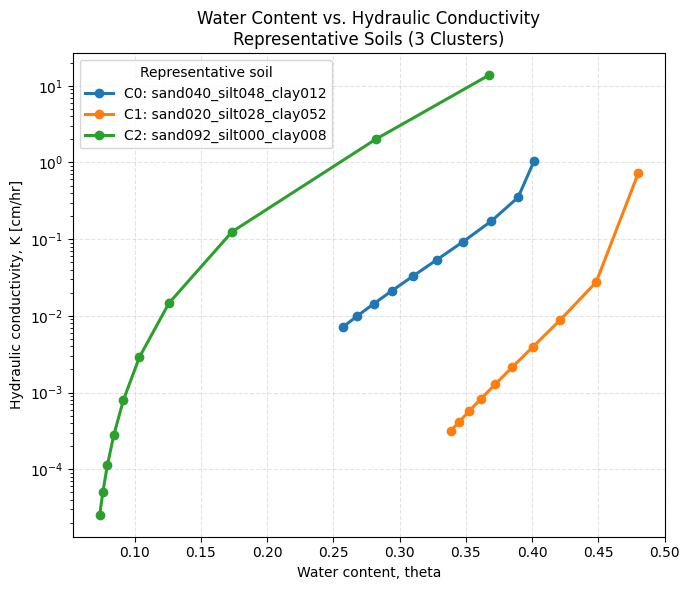

In [310]:
# Pressure-head values requested by advisor
pressure_head_cm = np.linspace(0, -300, 10)

fig, ax = plt.subplots(figsize=(7, 6))

for _, row in centroids.sort_values("cluster").iterrows():

    cluster_id = int(row["cluster"])
    scenario_name = row["representative_soil"]

    params = scenarios_to_run[scenario_name]

    theta_curve = theta_vg_pressure_head(
        psi_cm=pressure_head_cm,
        theta_r=params["theta_r"],
        theta_s=params["theta_s"],
        alpha=params["alpha"],
        vg_n=params["vg_n"]
    )

    k_curve = k_vg_pressure_head(
        psi_cm=pressure_head_cm,
        theta_r=params["theta_r"],
        theta_s=params["theta_s"],
        alpha=params["alpha"],
        vg_n=params["vg_n"],
        Ks=params["Ks"],
        l=params.get("l", 0.5)
    )

    ax.plot(
        theta_curve,
        k_curve,
        marker="o",
        linewidth=2.2,
        label=f"C{cluster_id}: {scenario_name}"
    )

ax.set_xlabel("Water content, theta")
ax.set_ylabel("Hydraulic conductivity, K [cm/hr]")
ax.set_title(f"Water Content vs. Hydraulic Conductivity\nRepresentative Soils ({k} Clusters)")

ax.set_yscale("log")
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(title="Representative soil")

plt.tight_layout()
plt.show()

### Water content vs Hydraulic conductivity for all soils grouped by cluster

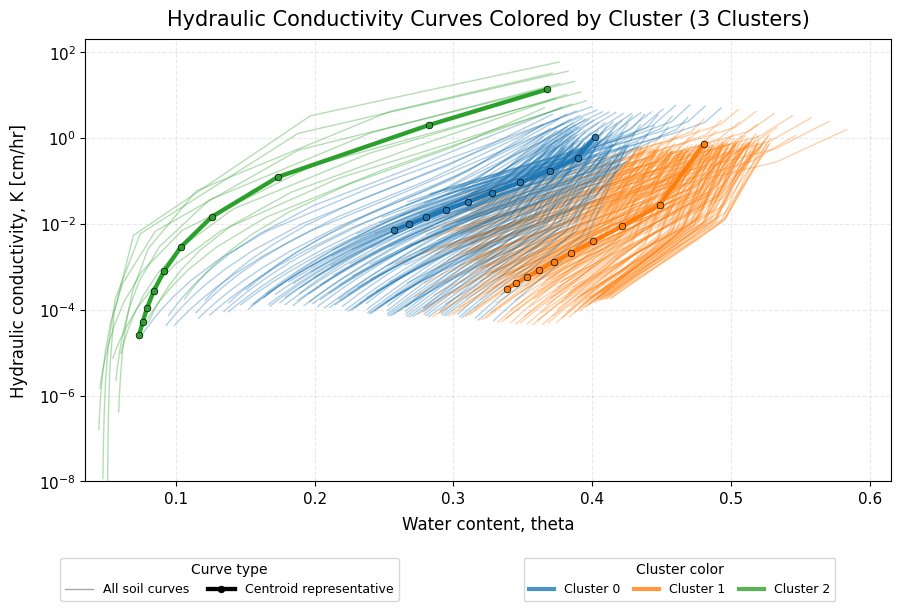

In [311]:
pressure_head_cm = np.linspace(0, -300, 10)

fig, ax = plt.subplots(figsize=(9, 6.8))

cmap = plt.get_cmap("tab10")

# -------------------------------------------------
# Plot all soils as background cluster-colored curves
# -------------------------------------------------
for _, row in all_soils_cluster_df.iterrows():

    scenario_name = row["soil"]
    cluster_id = int(row["cluster"])
    params = scenarios_to_run[scenario_name]

    theta_curve = theta_vg_pressure_head(
        psi_cm=pressure_head_cm,
        theta_r=params["theta_r"],
        theta_s=params["theta_s"],
        alpha=params["alpha"],
        vg_n=params["vg_n"]
    )

    k_curve = k_vg_pressure_head(
        psi_cm=pressure_head_cm,
        theta_r=params["theta_r"],
        theta_s=params["theta_s"],
        alpha=params["alpha"],
        vg_n=params["vg_n"],
        Ks=params["Ks"],
        l=params.get("l", 0.5)
    )

    ax.plot(
        theta_curve,
        k_curve,
        color=cmap(cluster_id),
        linewidth=1.0,
        alpha=0.35,
        zorder=1
    )

# -------------------------------------------------
# Plot representative centroid soils in bold cluster colors
# -------------------------------------------------
rep_handles = []

for _, row in centroids.sort_values("cluster").iterrows():

    cluster_id = int(row["cluster"])
    scenario_name = row["representative_soil"]
    params = scenarios_to_run[scenario_name]

    theta_curve = theta_vg_pressure_head(
        psi_cm=pressure_head_cm,
        theta_r=params["theta_r"],
        theta_s=params["theta_s"],
        alpha=params["alpha"],
        vg_n=params["vg_n"]
    )

    k_curve = k_vg_pressure_head(
        psi_cm=pressure_head_cm,
        theta_r=params["theta_r"],
        theta_s=params["theta_s"],
        alpha=params["alpha"],
        vg_n=params["vg_n"],
        Ks=params["Ks"],
        l=params.get("l", 0.5)
    )

    line, = ax.plot(
        theta_curve,
        k_curve,
        color=cmap(cluster_id),
        linewidth=3.1,
        alpha=1.0,
        linestyle="-",
        marker="o",
        markersize=4.8,
        markeredgecolor="black",
        markeredgewidth=0.5,
        zorder=5,
        label=f"C{cluster_id} representative"
    )

    rep_handles.append(line)

# -------------------------------------------------
# Axes formatting
# -------------------------------------------------
ax.set_xlabel("Water content, theta", fontsize=12, labelpad=7)
ax.set_ylabel("Hydraulic conductivity, K [cm/hr]", fontsize=12, labelpad=8)

ax.set_title(
    f"Hydraulic Conductivity Curves Colored by Cluster ({k} Clusters)",
    fontsize=15,
    pad=10
)

ax.set_xlim(0.035, 0.615)
ax.set_yscale("log")
ax.set_ylim(1e-8, 2e2)

ax.grid(True, linestyle="--", alpha=0.28)
ax.tick_params(labelsize=11)

# -------------------------------------------------
# Legend handles
# -------------------------------------------------
cluster_handles = [
    plt.Line2D(
        [0], [0],
        color=cmap(int(cluster_id)),
        linewidth=3,
        alpha=0.8,
        label=f"Cluster {int(cluster_id)}"
    )
    for cluster_id in sorted(all_soils_cluster_df["cluster"].unique())
]

style_handles = [
    plt.Line2D(
        [0], [0],
        color="black",
        linewidth=1.0,
        alpha=0.35,
        label="All soil curves"
    ),
    plt.Line2D(
        [0], [0],
        color="black",
        linewidth=3.1,
        marker="o",
        markersize=4.8,
        markeredgecolor="black",
        markeredgewidth=0.5,
        label="Centroid representative"
    )
]

# -------------------------------------------------
# Compact legends below graph
# -------------------------------------------------
fig.legend(
    handles=style_handles,
    title="Curve type",
    loc="lower center",
    bbox_to_anchor=(0.25, 0.045),
    ncol=2,
    frameon=True,
    fontsize=9.0,
    title_fontsize=10.0,
    handlelength=2.2,
    columnspacing=1.5
)

fig.legend(
    handles=cluster_handles,
    title="Cluster color",
    loc="lower center",
    bbox_to_anchor=(0.75, 0.045),
    ncol=len(cluster_handles),
    frameon=True,
    fontsize=9.0,
    title_fontsize=10.0,
    handlelength=2.0,
    columnspacing=1.1
)

# -------------------------------------------------
# Keep most space for the graph while leaving room for legends
# -------------------------------------------------
fig.subplots_adjust(
    left=0.09,
    right=0.985,
    top=0.88,
    bottom=0.23
)

plt.show()